# Portfolio Risk & Return Analytics

**Разделы:**
1. Определение портфеля
2. Загрузка данных
3. Проверка качества данных
4. Доходности и базовая статистика
5. Волатильность и корреляционная матрица
6. VaR / CVaR
7. Sharpe / Sortino ratio
8. PCA на ковариационной матрице
9. Efficient Frontier (Markowitz)
10. Выводы


## 0. Импорты

In [1]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.optimize import minimize
from scipy import stats

plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.float_format = '{:.4f}'.format


## 1. Определение портфеля



In [2]:
portfolio = {
    'PG': 0.15,
    'KHC': 0.10,
    'SIRI': 0.05,
    'OKTA': 0.15,
    'S': 0.30,
    'PFE': 0.20,
    'FUSD.L': 0.05,
    
}

benchmarks = [
    "SPY",
    "QQQ"
]

assert abs(sum(portfolio.values()) - 1.0) < 1e-6, "Веса должны суммироваться в 1.0"

tickers = list(portfolio.keys())
weights = np.array(list(portfolio.values()))
all_tickers = tickers + benchmarks

print(f"Активов в портфеле: {len(tickers)}")
print(f"Сумма весов: {sum(portfolio.values()):.2f}")


Активов в портфеле: 7
Сумма весов: 1.00


## 2. Загрузка данных

Используем Adjusted Close (учитывает дивиденды и сплиты) минимум за 3-5 лет.


In [3]:
START_DATE = '2022-02-01'
END_DATE = '2026-07-25'

raw_data = yf.download(all_tickers, start=START_DATE, end=END_DATE, auto_adjust=True)
prices = raw_data['Close']


print(f"Период: {prices.index.min().date()} — {prices.index.max().date()}")
print(f"Количество торговых дней: {len(prices)}")
prices.head(1600)


[*********************100%***********************]  9 of 9 completed


Период: 2022-02-01 — 2026-07-24
Количество торговых дней: 1152


Ticker,FUSD.L,KHC,OKTA,PFE,PG,QQQ,S,SIRI,SPY
Date,,,,,,,,,
2022-02-01,8.0926,28.8406,201.4200,41.4023,142.1182,355.5801,46.8900,56.6393,426.1893
2022-02-02,8.1628,29.0402,191.2400,42.0186,144.6627,358.4693,43.8900,55.9690,430.3293
2022-02-03,8.2058,28.6091,182.8000,41.6441,146.0328,343.9356,40.9000,55.8852,420.2144
2022-02-04,8.0405,27.7390,188.8600,41.3477,143.7107,348.2743,42.8500,56.8069,422.1904
2022-02-07,8.0846,27.7151,188.0900,41.5115,142.6342,345.4727,43.6700,56.4717,420.8355
...,...,...,...,...,...,...,...,...,...
2026-07-20,13.4500,25.8600,148.4100,24.3245,148.0250,696.0600,19.4600,30.6000,742.0900
2026-07-21,13.4500,25.7900,141.7100,24.5112,147.0026,708.9700,18.8100,30.2900,748.2800
2026-07-22,13.4750,25.9600,136.6900,24.3933,148.0250,705.3500,18.2200,29.8300,747.4100


## 3. Проверка качества данных


In [4]:
# Пропущенные значения
missing = prices.isna().sum()
print("Пропущенные значения по тикерам:")
print(missing[missing > 0] if missing.sum() > 0 else "Пропусков нет")

# Заполнение небольших пропусков (праздники на разных биржах и т.п.)
prices_clean = prices.ffill().dropna()

# Проверка на аномальные скачки (потенциальные ошибки в данных)
daily_returns_check = prices_clean.pct_change().dropna()
extreme_moves = daily_returns_check[(daily_returns_check.abs() > 0.20)]
print(f"\nДней с движением >20% (проверить на ошибки данных): {extreme_moves.count().sum()}")
if extreme_moves.count().sum() > 0:
    display(extreme_moves.dropna(how='all'))


Пропущенные значения по тикерам:
Ticker
FUSD.L    23
KHC       29
OKTA      30
PFE       29
PG        30
QQQ       29
S         29
SIRI      29
SPY       29
dtype: int64

Дней с движением >20% (проверить на ошибки данных): 7


Ticker,FUSD.L,KHC,OKTA,PFE,PG,QQQ,S,SIRI,SPY
Date,,,,,,,,,
2022-09-01,NaN,NaN,-0.3370,NaN,NaN,NaN,NaN,NaN,NaN
2022-12-01,NaN,NaN,0.2646,NaN,NaN,NaN,NaN,NaN,NaN
2023-06-02,NaN,NaN,NaN,NaN,NaN,NaN,-0.3514,NaN,NaN
2023-07-20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.4226,NaN
2024-02-29,NaN,NaN,0.2291,NaN,NaN,NaN,NaN,NaN,NaN
2025-03-04,NaN,NaN,0.2427,NaN,NaN,NaN,NaN,NaN,NaN
2026-05-29,NaN,NaN,0.3014,NaN,NaN,NaN,NaN,NaN,NaN


### рассчитываем дневные доходности 

In [5]:
returns = prices.pct_change().dropna()

### рассчитываем экстремальные дневные доходности >20%

In [6]:
extreme_moves = returns[returns.abs().gt(0.2).any(axis=1)]
print(extreme_moves)

Ticker      FUSD.L     KHC    OKTA     PFE      PG     QQQ       S    SIRI  \
Date                                                                         
2022-09-01 -0.0127  0.0080 -0.3370  0.0310  0.0123  0.0004 -0.0590  0.0066   
2022-12-01  0.0245  0.0036  0.2646  0.0190  0.0006  0.0012  0.0366 -0.0123   
2023-06-02  0.0175  0.0084 -0.0115  0.0089  0.0178  0.0075 -0.3514 -0.0324   
2023-07-20  0.0011  0.0072 -0.0087  0.0091  0.0081 -0.0231 -0.0600  0.4226   
2024-02-29  0.0031 -0.0073  0.2291 -0.0178 -0.0069  0.0086 -0.0018 -0.0023   
2025-03-04 -0.0269 -0.0109  0.2427 -0.0190 -0.0137 -0.0030 -0.0119 -0.0162   
2026-05-29  0.0026 -0.0188  0.3014  0.0015 -0.0161  0.0037 -0.0816 -0.0117   

Ticker         SPY  
Date                
2022-09-01  0.0031  
2022-12-01 -0.0007  
2023-06-02  0.0145  
2023-07-20 -0.0066  
2024-02-29  0.0036  
2025-03-04 -0.0118  
2026-05-29  0.0025  


### оставляем только активы, которые дали экстремальные дневные доходности >20%

In [7]:
extreme_events = (
    returns.where(returns.abs() > 0.2)
    .melt(
        ignore_index=False,
        var_name="Ticker",
        value_name="Return"
    )
    .dropna()
    .reset_index()
)

extreme_events.columns = [
    "Date",
    "Ticker",
    "Return"
]

print(extreme_events)

extreme_events.to_csv(
    "../reports/extreme_events.csv",
    index=False)

        Date Ticker  Return
0 2022-09-01   OKTA -0.3370
1 2022-12-01   OKTA  0.2646
2 2024-02-29   OKTA  0.2291
3 2025-03-04   OKTA  0.2427
4 2026-05-29   OKTA  0.3014
5 2023-06-02      S -0.3514
6 2023-07-20   SIRI  0.4226


## 4. Доходности и базовая статистика

In [27]:
returns = prices_clean.pct_change().dropna()

# Годовая доходность и волатильность по активам
annual_return = returns[tickers].mean() * 252
annual_vol = returns[tickers].std() * np.sqrt(252)

stats_table = pd.DataFrame({
    'Annual Return': annual_return,
    'Annual Volatility': annual_vol,
    'Sharpe (rf=0)': annual_return / annual_vol
}).sort_values('Sharpe (rf=0)', ascending=False)

stats_table.style.format({
    'Annual Return': "{:.2%}",
    'Annual Volatility': "{:.2%}"}
)


,Annual Return,Annual Volatility,Sharpe (rf=0)
Ticker,,,
FUSD.L,12.21%,14.45%,0.845182
OKTA,8.45%,58.27%,0.145029
PG,2.24%,18.25%,0.122818
KHC,0.09%,22.90%,0.003864
S,-1.59%,61.19%,-0.025993
SIRI,-3.78%,46.16%,-0.081930
PFE,-8.57%,24.01%,-0.357093


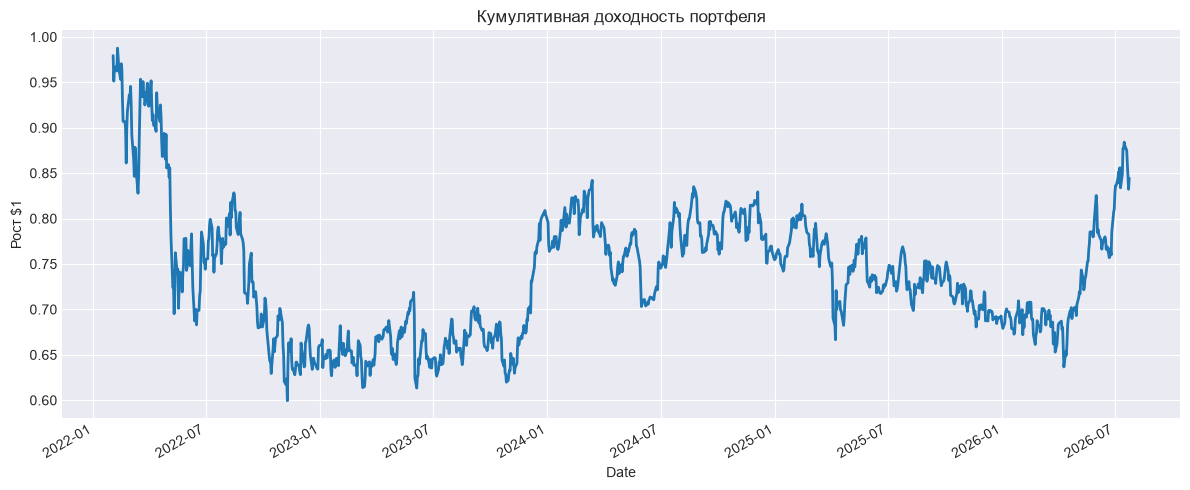

In [39]:
# Доходность портфеля
portfolio_returns = (returns[tickers] * weights).sum(axis=1)
cumulative_returns = (1 + portfolio_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 5))
cumulative_returns.plot(ax=ax, linewidth=2)
ax.set_title('Кумулятивная доходность портфеля')
ax.set_ylabel('Рост $1')
plt.tight_layout()
plt.show()

In [38]:
annual_portfolio_return = portfolio_returns.mean() * 252
print(f"Годовая доходность портфеля: {annual_portfolio_return:.2%}")

Годовая доходность портфеля: -0.16%


In [61]:
portfolio_growth = (1 + portfolio_returns).cumprod()

years = (
    portfolio_returns.index[-1] -
    portfolio_returns.index[0]
).days / 365.25

cagr = portfolio_growth.iloc[-1] ** (1 / years) - 1

print(f"CAGR: {cagr:.2%}")

CAGR: -3.71%


## 5. Волатильность и корреляционная матрица

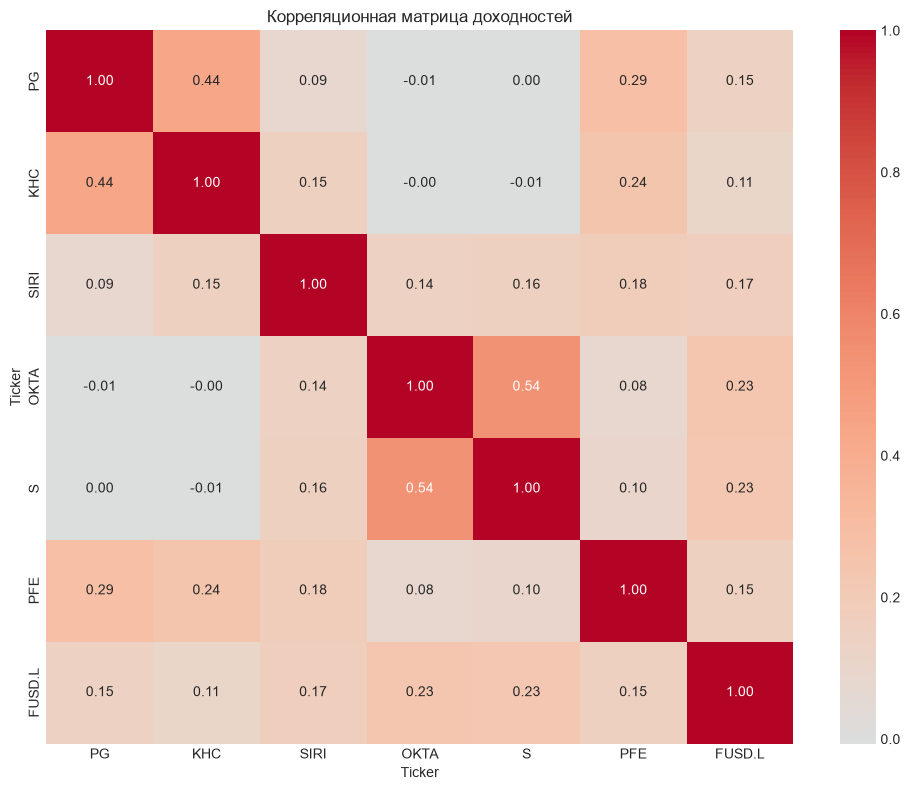

In [10]:
corr_matrix = returns[tickers].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, ax=ax)
ax.set_title('Корреляционная матрица доходностей')
plt.tight_layout()
plt.show()


In [11]:
# Ковариационная матрица (годовая) — нужна для VaR, PCA и Markowitz
cov_matrix_annual = returns[tickers].cov() * 252

portfolio_variance = weights @ cov_matrix_annual @ weights
portfolio_vol = np.sqrt(portfolio_variance)

print(f"Годовая волатильность портфеля: {portfolio_vol:.2%}")


Годовая волатильность портфеля: 26.60%


In [12]:
# Маржинальный вклад каждого актива в риск
marginal_contribution = (cov_matrix_annual @ weights) / portfolio_vol

# Компонентный вклад в риск
risk_contribution = weights * marginal_contribution

# В процентах от общего риска
risk_contribution_pct = risk_contribution / portfolio_vol


risk_table = pd.DataFrame({
    "Asset": returns[tickers].columns,
    "Weight": weights,
    "Risk Contribution": risk_contribution_pct
})

risk_table = risk_table.sort_values(
    "Risk Contribution",
    ascending=False
)

risk_table["Weight"] = risk_table["Weight"].map(lambda x: f"{x:.1%}")
risk_table["Risk Contribution"] = risk_table["Risk Contribution"].map(lambda x: f"{x:.1%}")

risk_table

,Asset,Weight,Risk Contribution
Ticker,,,
S,S,30.0%,62.5%
OKTA,OKTA,15.0%,24.1%
PFE,PFE,20.0%,6.3%
SIRI,SIRI,5.0%,2.6%
PG,PG,15.0%,2.1%
KHC,KHC,10.0%,1.6%
FUSD.L,FUSD.L,5.0%,0.9%


In [13]:
print(
    f"Сумма вкладов в риск: {risk_contribution_pct.sum():.2%}"
)

Сумма вкладов в риск: 100.00%


In [40]:
# Волатильность каждого актива
asset_vol = returns[tickers].std() * np.sqrt(252)

risk_vol_table = pd.DataFrame({
    "Volatility": asset_vol,
    "Weight": weights,
    "Risk Contribution": risk_contribution_pct
}).sort_values(
    "Risk Contribution",
    ascending=False,

)

risk_vol_table.style.format({
    "Volatility": "{:.2%}",
    "Weight": "{:.2%}",
    "Risk Contribution": "{:.2%}"
})

,Volatility,Weight,Risk Contribution
Ticker,,,
S,61.19%,30.00%,62.47%
OKTA,58.27%,15.00%,24.09%
PFE,24.01%,20.00%,6.25%
SIRI,46.16%,5.00%,2.60%
PG,18.25%,15.00%,2.08%
KHC,22.90%,10.00%,1.61%
FUSD.L,14.45%,5.00%,0.90%


In [15]:
risk_vol_table.Volatility.mean()

np.float64(0.35034151296723387)

### Рассчитаем волатильность без учета актива с самым высоким Risk Contribution

In [16]:
# TEST VOLATILITY WITHOUT - S

weights_without_S = weights.copy()

weights_without_S[0] = 0

# перераспределяем оставшийся капитал пропорционально
weights_without_S = weights_without_S / weights_without_S.sum()

vol_without_S = np.sqrt(
    weights_without_S @ cov_matrix_annual @ weights_without_S
)

print(f"Было: {portfolio_vol:.2%}")
print(f"Без S: {vol_without_S:.2%}")

Было: 26.60%
Без S: 30.80%


### Попробуем снизить вес актива S до 10%

In [17]:
new_weights = weights.copy()

# уменьшаем S с 20% до 10%
new_weights[0] = 0.10

# нормализуем остальные веса обратно до 90%
new_weights[1:] = new_weights[1:] / new_weights[1:].sum() * 0.90


new_vol = np.sqrt(
    new_weights @ cov_matrix_annual @ new_weights
)

print(f"Новая волатильность: {new_vol:.2%}")

Новая волатильность: 27.96%


In [18]:
print(new_weights.sum())

1.0


In [41]:
# ПЕРЕБИРАЕМ S для поиска оптимального размера позиции
results = []

for s_weight in np.arange(0, 0.41, 0.05):
    test_weights = weights.copy()
    
    difference = test_weights[0] - s_weight
    test_weights[0] = s_weight
    
    test_weights[1:] += (
        test_weights[1:] / test_weights[1:].sum()
    ) * difference
    
    vol = np.sqrt(
        test_weights @ cov_matrix_annual @ test_weights
    )
    
    results.append({
        "S_weight": s_weight,
        "Volatility": vol
    })

pd.DataFrame(results)

,S_weight,Volatility
0,0.0000,0.3080
1,0.0500,0.2937
2,0.1000,0.2796
3,0.1500,0.2660
4,0.2000,0.2527
5,0.2500,0.2399
6,0.3000,0.2277
7,0.3500,0.2162
8,0.4000,0.2054


## 6. Value at Risk (VaR) и Conditional VaR (CVaR)

Два метода: параметрический (предполагает нормальность) и исторический (без предположений о распределении).


In [20]:
confidence_level = 0.95
portfolio_mean = portfolio_returns.mean()
portfolio_std = portfolio_returns.std()

# Параметрический VaR (предполагает нормальное распределение)
z_score = stats.norm.ppf(1 - confidence_level)
var_parametric = -(portfolio_mean + z_score * portfolio_std)

# Исторический VaR (эмпирический перцентиль, без предположений)
var_historical = -portfolio_returns.quantile(1 - confidence_level)

# CVaR (Expected Shortfall) — среднее по хвосту хуже VaR
cvar_historical = -portfolio_returns[portfolio_returns <= -var_historical].mean()

print(f"Daily VaR (95%, parametric): {var_parametric:.2%}")
print(f"Daily VaR (95%, historical): {var_historical:.2%}")
print(f"Daily CVaR (95%, historical): {cvar_historical:.2%}")
print(f"\nАннуализированный VaR (95%, historical): {var_historical * np.sqrt(252):.2%}")


Daily VaR (95%, parametric): 2.76%
Daily VaR (95%, historical): 2.77%
Daily CVaR (95%, historical): 3.89%

Аннуализированный VaR (95%, historical): 44.05%


## 7. Sharpe и Sortino Ratio

In [43]:
risk_free_rate = 0.04  # подставь актуальную безрисковую ставку (например, 3-мес T-bill)

annual_portfolio_vol = portfolio_returns.std() * np.sqrt(252)

sharpe_ratio = (annual_portfolio_return - risk_free_rate) / annual_portfolio_vol

# Sortino: учитывает только downside volatility, не наказывает за "хорошую" волатильность вверх
downside_returns = portfolio_returns[portfolio_returns < 0]
downside_vol = downside_returns.std() * np.sqrt(252)
sortino_ratio = (annual_portfolio_return - risk_free_rate) / downside_vol

print(f"Годовая волатильность портфеля: {annual_portfolio_vol:.2%}")
print(f"Sharpe Ratio: {sharpe_ratio:.2f}")
print(f"Sortino Ratio: {sortino_ratio:.2f}")


Годовая волатильность портфеля: 26.60%
Sharpe Ratio: -0.16
Sortino Ratio: -0.22


## 8. Maximum Drawdown

In [47]:
cumulative = (1 + portfolio_returns).cumprod()

peak = cumulative.cummax()

drawdown = (cumulative - peak) / peak

max_drawdown = drawdown.min()

print(f"Max Drawdown: {max_drawdown:.2%}")

Max Drawdown: -39.31%


## 9. Calmar Ratio

In [48]:
calmar = cagr / abs(max_drawdown)

print(f"Calmar ratio: {calmar:.2f}")

Calmar ratio: -0.08


## 10. Rolling Sharpe / Rolling Volatility

<Axes: title={'center': 'Rolling 1Y Sharpe'}, xlabel='Date'>

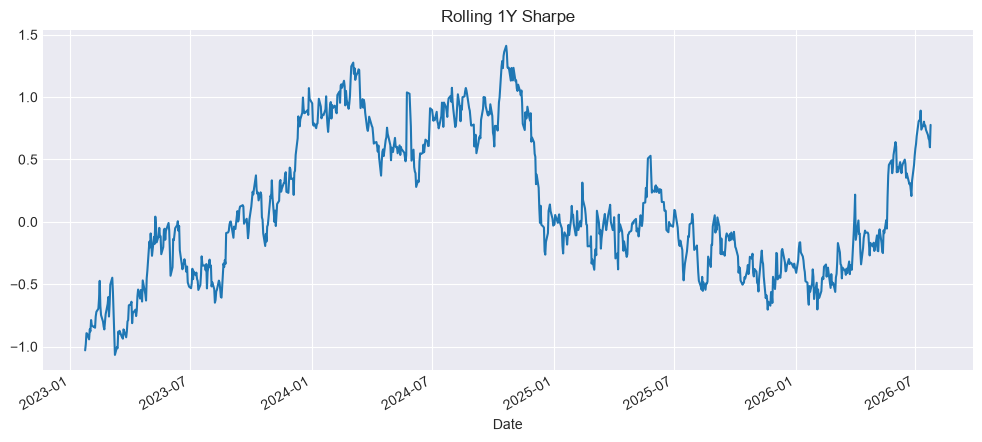

In [50]:
rolling_sharpe = (
    portfolio_returns
    .rolling(252)
    .mean()
    /
    portfolio_returns
    .rolling(252)
    .std()
) * np.sqrt(252)


rolling_sharpe.plot(
    figsize=(12,5),
    title="Rolling 1Y Sharpe"
)

<Axes: title={'center': 'Portfolio Drawdown'}, xlabel='Date'>

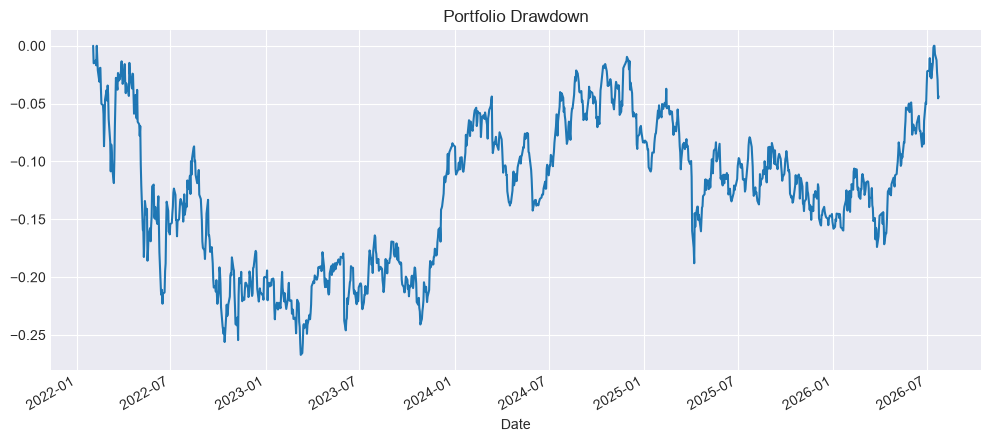

In [ ]:
rolling_max = (
    portfolio_growth
    .cummax()
)

rolling_dd = (
    portfolio_growth - rolling_max
) / rolling_max


rolling_dd.plot(
    figsize=(12,5),
    title="Portfolio Drawdown"
)

## 11. PCA на ковариационной матрице

Показывает, сколько "независимых источников риска" реально определяют движение портфеля —
если первая компонента объясняет 70%+ дисперсии, портфель менее диверсифицирован, чем кажется по числу активов.


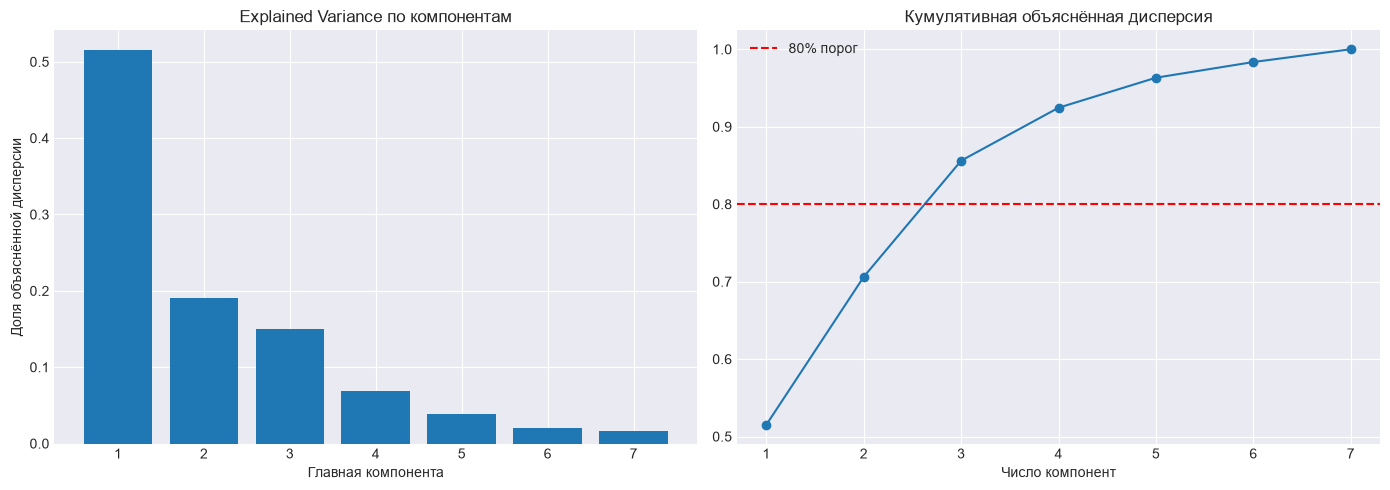

Первая компонента объясняет 51.5% дисперсии портфеля


In [ ]:
from sklearn.decomposition import PCA

pca = PCA()
pca.fit(returns)

explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].bar(range(1, len(explained_var) + 1), explained_var)
axes[0].set_title('Explained Variance по компонентам')
axes[0].set_xlabel('Главная компонента')
axes[0].set_ylabel('Доля объяснённой дисперсии')

axes[1].plot(range(1, len(cumulative_var) + 1), cumulative_var, marker='o')
axes[1].axhline(0.8, color='red', linestyle='--', label='80% порог')
axes[1].set_title('Кумулятивная объяснённая дисперсия')
axes[1].set_xlabel('Число компонент')
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Первая компонента объясняет {explained_var[0]:.1%} дисперсии портфеля")


## 12. Efficient Frontier (Марковиц)

Строим границу эффективных портфелей методом Monte Carlo + точную оптимизацию через scipy.


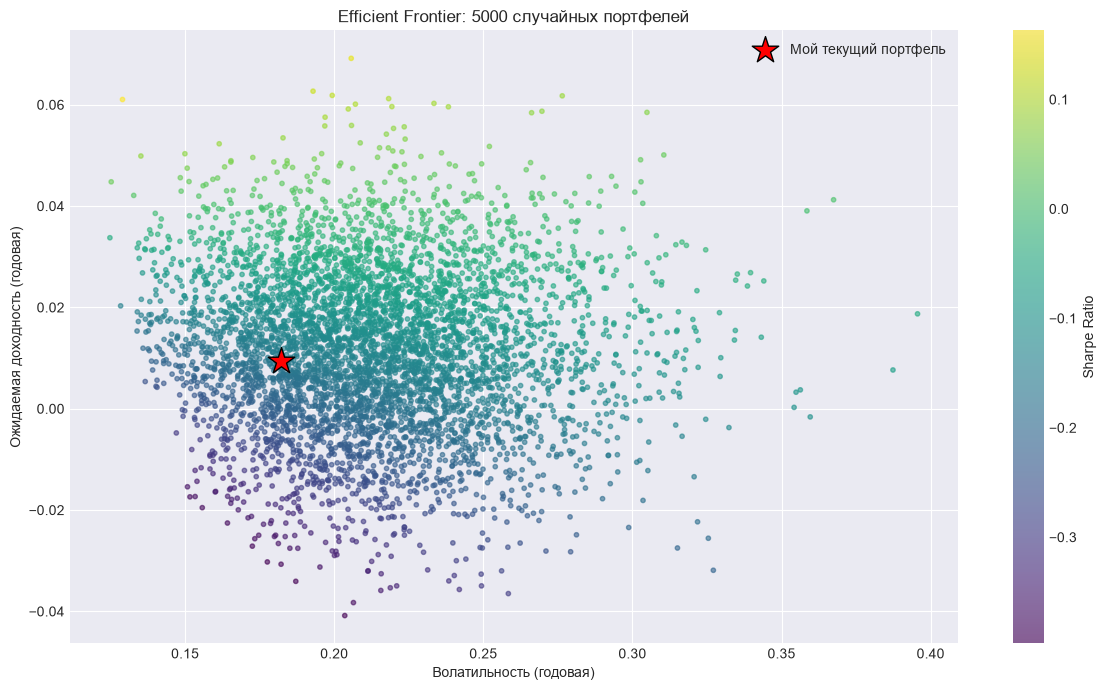

In [ ]:
n_assets = len(tickers)
n_portfolios = 5000

results = np.zeros((3, n_portfolios))
all_weights = np.zeros((n_portfolios, n_assets))

np.random.seed(42)
for i in range(n_portfolios):
    w = np.random.random(n_assets)
    w /= w.sum()
    all_weights[i, :] = w

    port_return = np.sum(w * annual_return)
    port_vol = np.sqrt(w @ cov_matrix_annual @ w)

    results[0, i] = port_return
    results[1, i] = port_vol
    results[2, i] = (port_return - risk_free_rate) / port_vol  # Sharpe

fig, ax = plt.subplots(figsize=(12, 7))
scatter = ax.scatter(results[1], results[0], c=results[2], cmap='viridis', alpha=0.6, s=10)
plt.colorbar(scatter, label='Sharpe Ratio')

# Твой текущий портфель на графике
ax.scatter(portfolio_vol, np.sum(weights * annual_return), color='red', marker='*', s=400,
           label='Мой текущий портфель', edgecolors='black', linewidths=1)

ax.set_xlabel('Волатильность (годовая)')
ax.set_ylabel('Ожидаемая доходность (годовая)')
ax.set_title('Efficient Frontier: 5000 случайных портфелей')
ax.legend()
plt.tight_layout()
plt.show()


In [70]:
from scipy.optimize import minimize

n_assets = len(tickers)

def neg_sharpe(w, mean_returns, cov_matrix, rf):
    port_return = np.sum(w * mean_returns)
    port_vol = np.sqrt(w @ cov_matrix @ w)
    return -(port_return - rf) / port_vol


constraints = (
    {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}
)

bounds = tuple((0, 1) for _ in range(n_assets))

init_guess = np.array(
    n_assets * [1. / n_assets]
)

optimal = minimize(
    neg_sharpe,
    init_guess,
    args=(
        annual_return,
        cov_matrix_annual,
        risk_free_rate
    ),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints
)

optimal_weights = pd.Series(
    optimal.x,
    index=tickers
).sort_values(
    ascending=False
)

print("Оптимальные веса (максимальный Sharpe ratio):")
print(optimal_weights)


Оптимальные веса (максимальный Sharpe ratio):
FUSD.L   1.0000
PG       0.0000
KHC      0.0000
SIRI     0.0000
OKTA     0.0000
S        0.0000
PFE      0.0000
dtype: float64


In [71]:
spy_returns = returns["SPY"]

In [72]:
comparison_returns = pd.concat(
    [
        portfolio_returns.rename("Portfolio"),
        spy_returns.rename("SPY")
    ],
    axis=1
)

comparison_returns.head()

,Portfolio,SPY
Date,,
2022-02-02,-0.0206,0.0097
2022-02-03,-0.0287,-0.0235
2022-02-04,0.0122,0.0047
2022-02-07,0.0047,-0.0032
2022-02-08,-0.0052,0.0082


In [73]:
def performance_metrics(returns, name):
    
    annual_return = returns.mean() * 252
    annual_vol = returns.std() * np.sqrt(252)

    sharpe = (annual_return - 0.04) / annual_vol

    cumulative = (1 + returns).cumprod()

    max_dd = (
        cumulative /
        cumulative.cummax()
        - 1
    ).min()

    return pd.Series(
        {
            "Annual Return": annual_return,
            "Volatility": annual_vol,
            "Sharpe": sharpe,
            "Max Drawdown": max_dd
        },
        name=name
    )

In [74]:
comparison = pd.concat(
    [
        performance_metrics(portfolio_returns, "Portfolio"),
        performance_metrics(spy_returns, "SPY")
    ],
    axis=1
)

comparison.T

,Annual Return,Volatility,Sharpe,Max Drawdown
Portfolio,-0.0016,0.2660,-0.1563,-0.3931
SPY,0.1354,0.1729,0.5517,-0.2209


In [75]:
import statsmodels.api as sm

X = spy_returns
y = portfolio_returns

X = sm.add_constant(X)

model = sm.OLS(y, X).fit()

alpha_daily = model.params.iloc[0]
beta = model.params.iloc[1]

alpha_annual = alpha_daily * 252

print(f"Beta: {beta:.2f}")
print(f"Alpha annual: {alpha_annual:.2%}")

Beta: 0.96
Alpha annual: -13.17%


In [76]:
periods = {
    "Full period": "2022-02-01",
    "2025 regime": "2025-01-01",
    "Last 12 months": "2025-07-25",
    "2026 YTD": "2026-01-01"
}

In [77]:
results = []

for name, start_date in periods.items():

    portfolio_period = portfolio_returns.loc[start_date:]
    spy_period = spy_returns.loc[start_date:]

    portfolio_metrics = performance_metrics(
        portfolio_period,
        "Portfolio"
    )

    spy_metrics = performance_metrics(
        spy_period,
        "SPY"
    )

    results.append({
        "Period": name,
        "Portfolio Return": portfolio_metrics["Annual Return"],
        "SPY Return": spy_metrics["Annual Return"],
        "Portfolio Vol": portfolio_metrics["Volatility"],
        "SPY Vol": spy_metrics["Volatility"],
        "Portfolio Sharpe": portfolio_metrics["Sharpe"],
        "SPY Sharpe": spy_metrics["Sharpe"],
        "Portfolio DD": portfolio_metrics["Max Drawdown"],
        "SPY DD": spy_metrics["Max Drawdown"]
    })


regime_analysis = pd.DataFrame(results)

regime_analysis

,Period,Portfolio Return,SPY Return,Portfolio Vol,SPY Vol,Portfolio Sharpe,SPY Sharpe,Portfolio DD,SPY DD
0,Full period,-0.0016,0.1354,0.2660,0.1729,-0.1563,0.5517,-0.3931,-0.2209
1,2025 regime,0.0959,0.1713,0.2252,0.1738,0.2483,0.7552,-0.2198,-0.1876
2,Last 12 months,0.1192,0.1682,0.2210,0.1256,0.3585,1.0210,-0.1720,-0.0888
3,2026 YTD,0.3924,0.1590,0.2390,0.1357,1.4743,0.8769,-0.1027,-0.0888


In [78]:
import statsmodels.api as sm

alpha_beta = []

for name, start_date in periods.items():

    p = portfolio_returns.loc[start_date:]
    m = spy_returns.loc[start_date:]

    X = sm.add_constant(m)

    model = sm.OLS(
        p,
        X
    ).fit()

    alpha_beta.append({
        "Period": name,
        "Beta": model.params.iloc[1],
        "Alpha": model.params.iloc[0] * 252
    })


pd.DataFrame(alpha_beta)

,Period,Beta,Alpha
0,Full period,0.9607,-0.1317
1,2025 regime,0.7257,-0.0284
2,Last 12 months,0.6353,0.0124
3,2026 YTD,0.5615,0.3032


### вклад активов в доходность

In [79]:
returns_2026 = returns.loc["2026-01-01":]

asset_return_2026 = (
    1 + returns_2026[tickers]
).prod() - 1

weights_series = pd.Series(
    weights,
    index=tickers
)

contribution = asset_return_2026 * weights_series

asset_return_2026 = pd.DataFrame({
    "Asset Return": asset_return_2026,
    "Weight": weights_series,
    "Contribution": contribution
}).sort_values(
    "Contribution",
    ascending=False
)

asset_return_2026.style.format({
    "Asset Return": "{:.2%}",
    "Weight": "{:.2%}",
    "Contribution": "{:.2%}"
})



,Asset Return,Weight,Contribution
OKTA,57.40%,15.00%,8.61%
S,20.93%,30.00%,6.28%
SIRI,52.43%,5.00%,2.62%
KHC,9.58%,10.00%,0.96%
PFE,3.64%,20.00%,0.73%
PG,4.06%,15.00%,0.61%
FUSD.L,9.60%,5.00%,0.48%


## 10. Выводы

*(Заполни после прогона на своих реальных данных)*

- Сравни свой текущий портфель с оптимальным по Sharpe — насколько ты близок к efficient frontier?
- Какая доля риска объясняется первой главной компонентой (концентрация риска)?
- Какие активы дают наибольший вклад в диверсификацию (низкая корреляция + позитивный Sharpe)?
- Ограничения анализа: исторические данные не гарантируют будущих корреляций и доходностей;
  здесь не учтены транзакционные издержки при ребалансировке.
